In [57]:
import numpy as np
import pandas as pd

# Data 

In [58]:
df_train = pd.read_csv('data/train.csv')
X_train_final = pd.read_csv('data/X_train.csv')

In [59]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [60]:
X_train_final.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1010.8,24.3,21.4,20.4,19.5,86.0,77.0,7.3,9.5,0.985139,...,-60.7,2464.7,3.4,0.3,28.8,-27.2,27.2,23.6,0.0,127.2
1,1012.0,26.5,24.4,23.3,22.2,90.0,88.0,0.6,37.5,0.908324,...,-70.8,1197.9,6.4,0.2,17.4,-11.1,11.1,53.0,0.2,14.2
2,1013.5,28.9,26.5,24.8,20.6,76.0,54.0,4.5,16.7,-0.970942,...,-50.6,2410.5,2.8,0.4,32.4,-27.1,27.1,82.8,0.1,11.6
3,1013.9,20.9,20.6,19.4,19.9,73.0,83.0,2.0,14.8,0.495009,...,-48.8,1207.3,4.0,0.6,23.7,-16.0,16.0,94.4,0.2,3.4
4,1013.4,27.8,24.4,23.1,22.1,87.0,88.0,1.6,13.0,0.974928,...,-69.2,1250.3,6.6,0.2,15.1,-14.5,14.5,4.4,0.0,55.1


# Normalization

In [61]:
import matplotlib.pyplot as plt

we will work on those columns: Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine', 'windspeed', 'rainfall', 'day_repaired_sin',
       'day_repaired_cos', 'winddirection_sin', 'winddirection_cos'],
      dtype='object')

In [62]:
columns = ['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
           'cloud', 'sunshine', 'windspeed', 'day_repaired_sin',
           'day_repaired_cos', 'winddirection_sin', 'winddirection_cos']
df = X_train_final[columns]

**Plots**

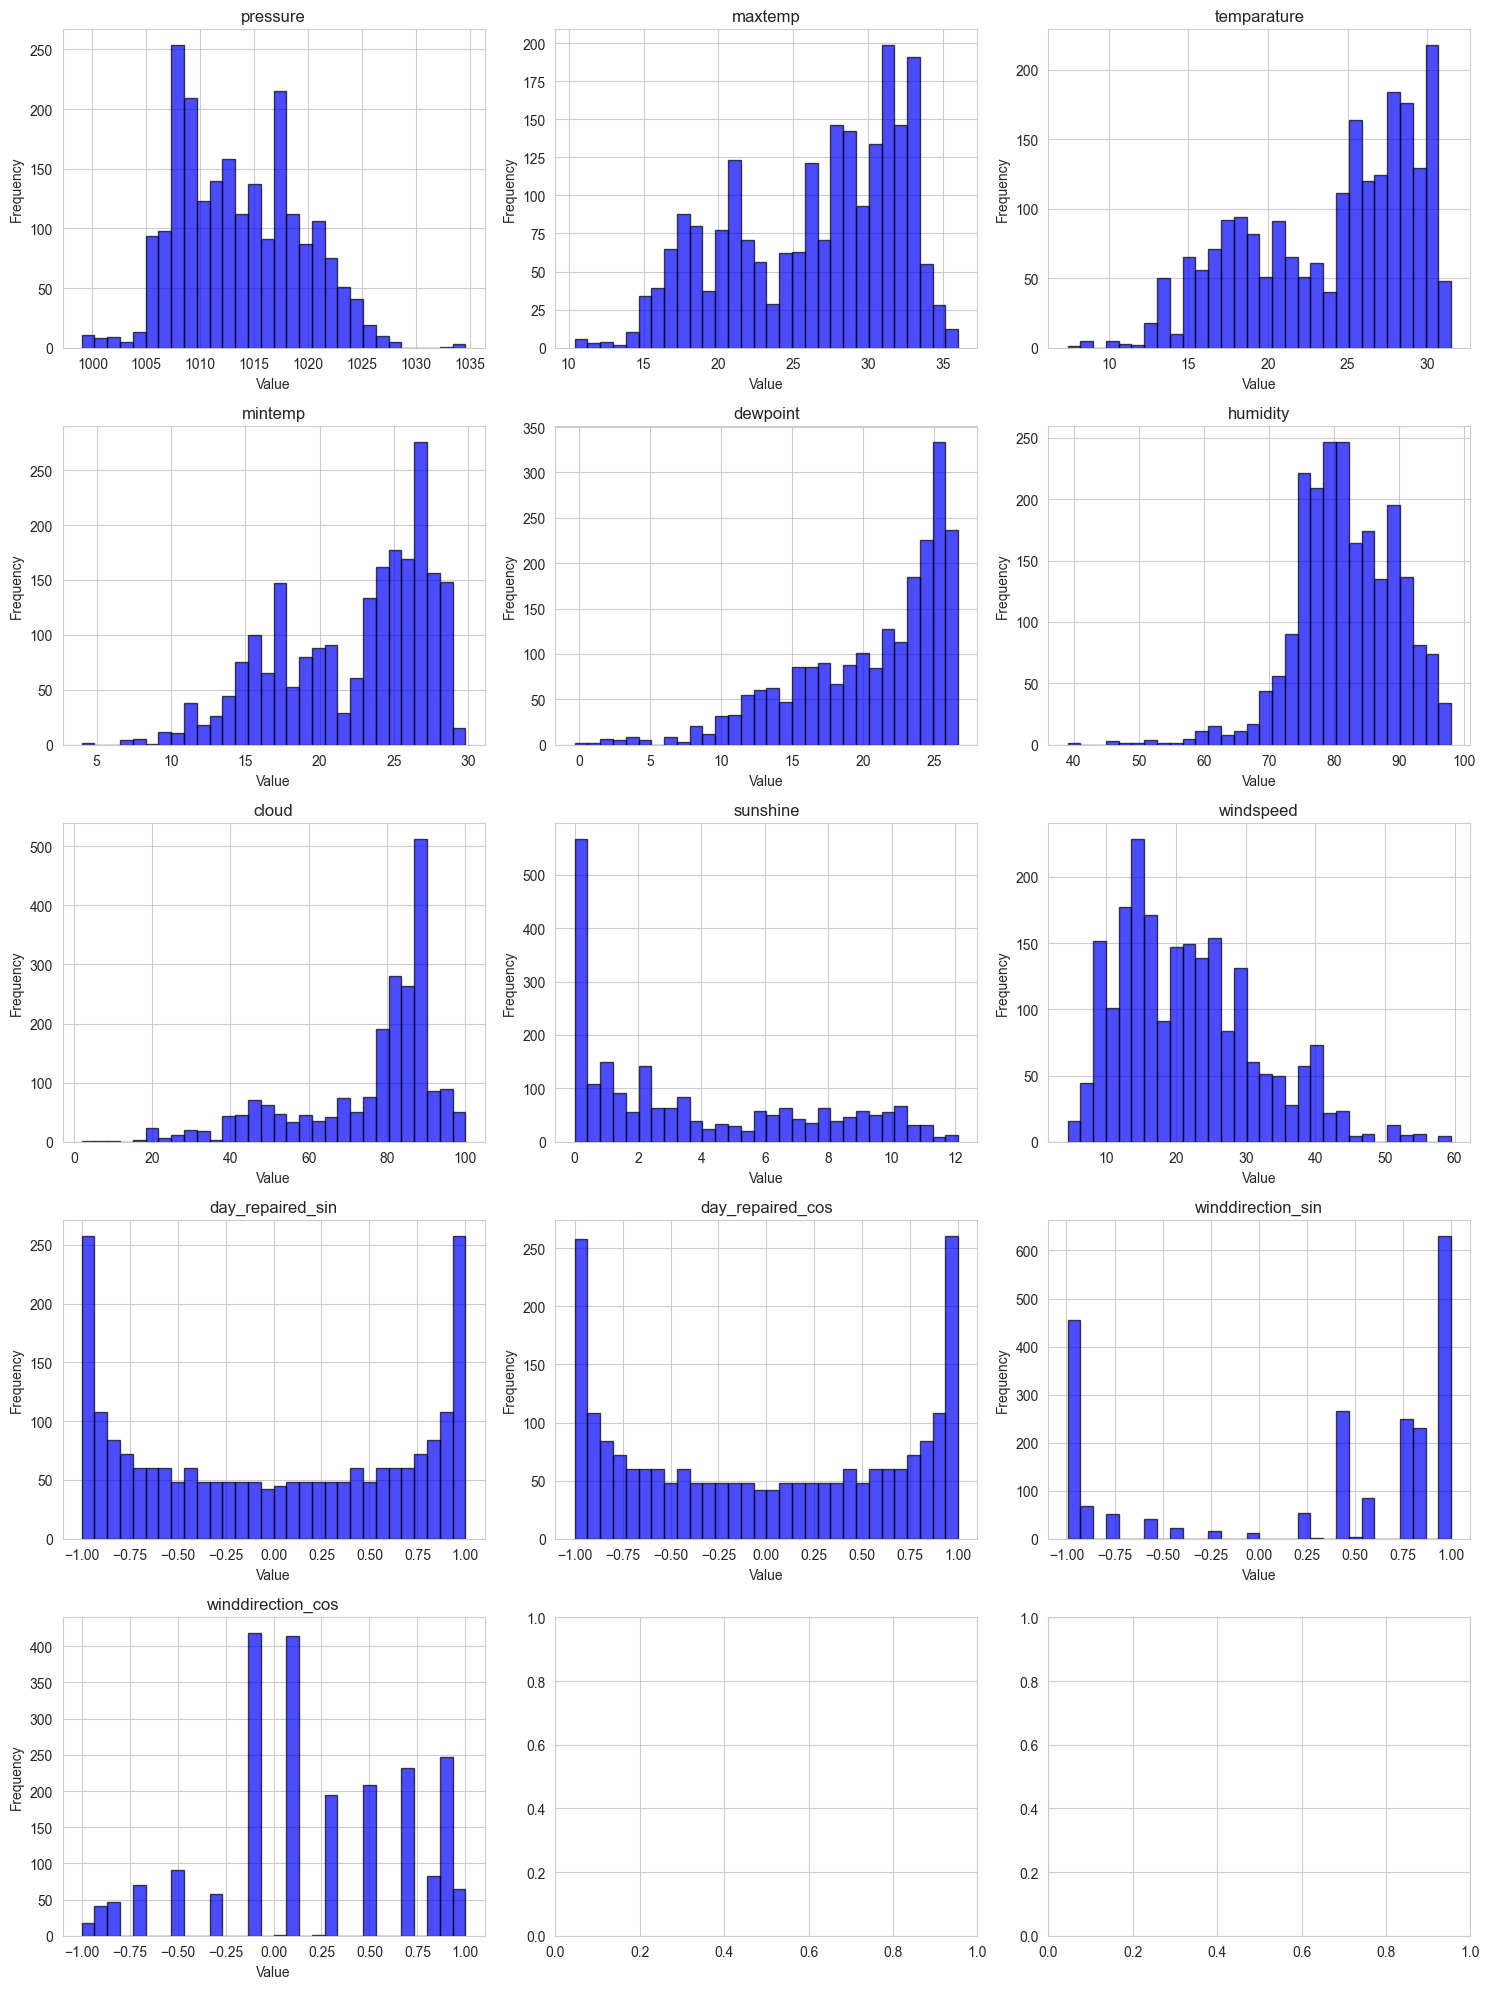

In [63]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    if col in df_train_final.columns:
        axes[i].hist(df_train_final[col], bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Standard-Scaling

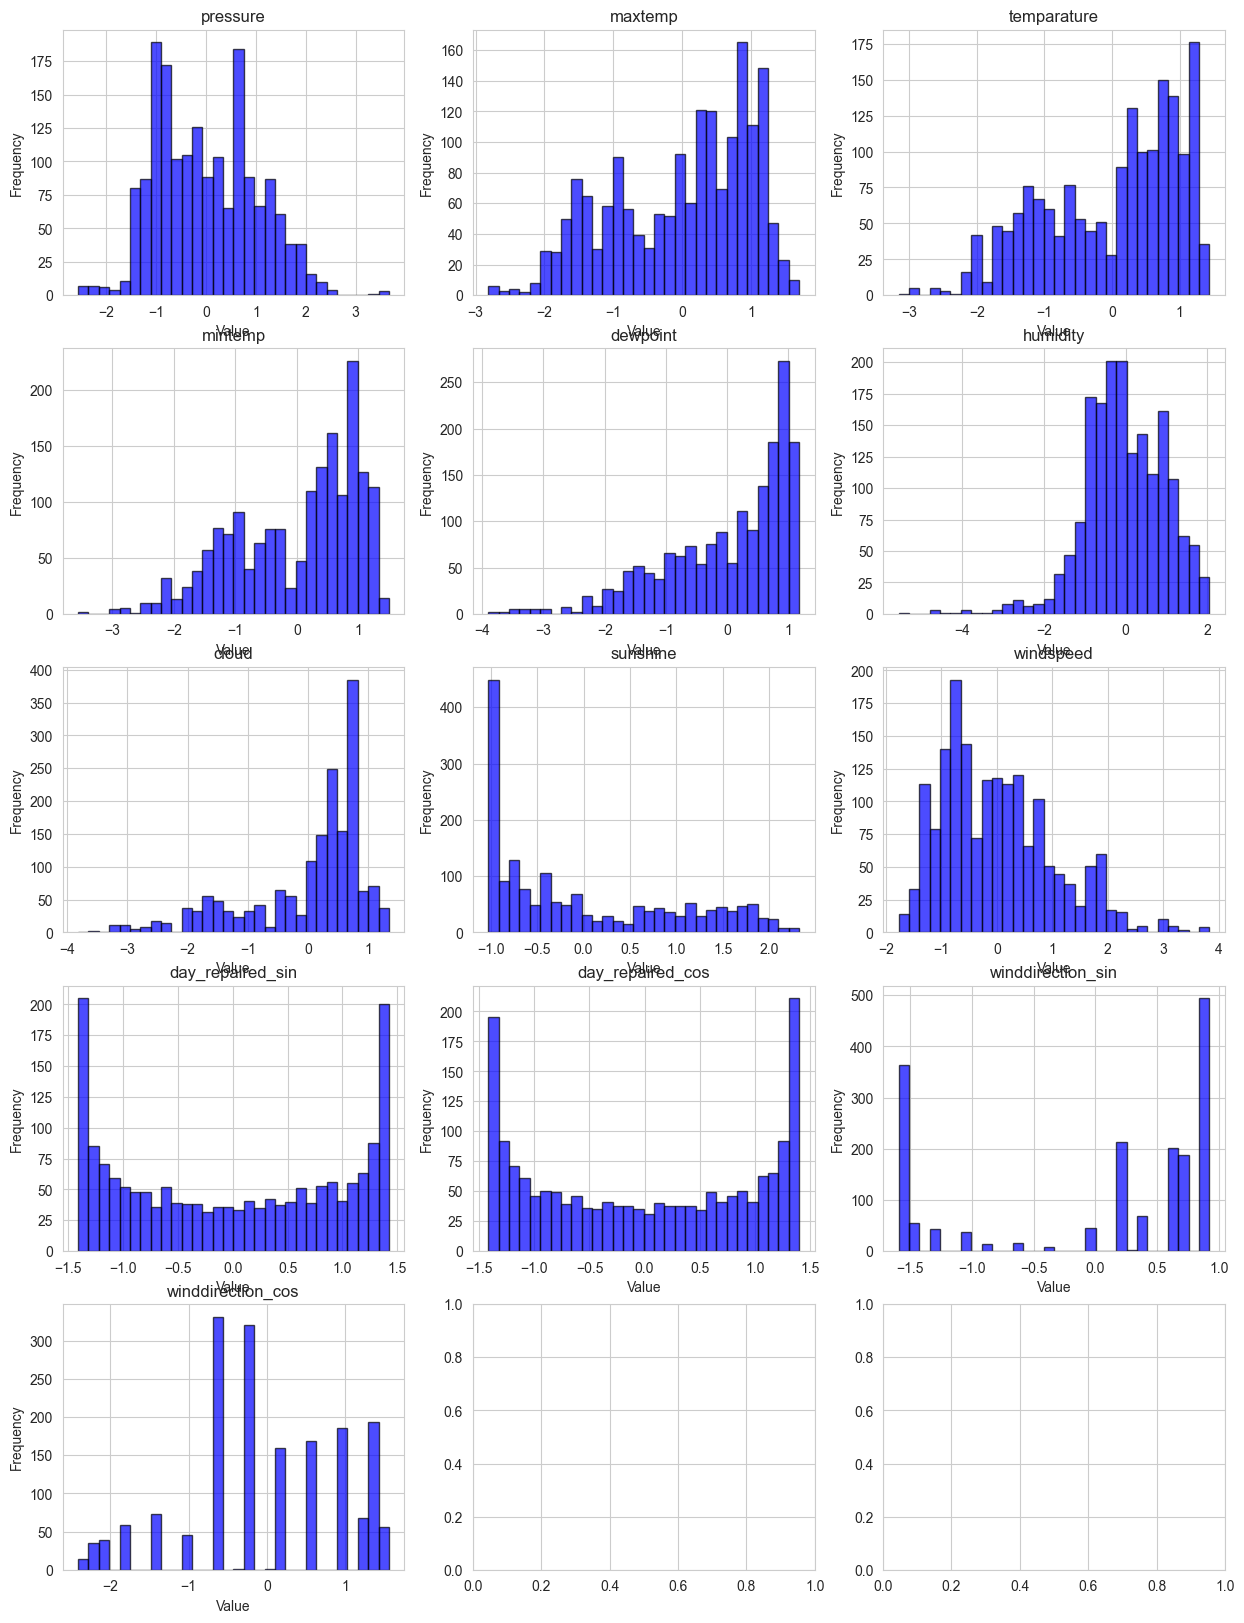

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_standardScaler = scaler.fit_transform(df)
data_standardScaler = pd.DataFrame(data_standardScaler, columns=columns)

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    if col in data_standardScaler.columns:
        axes[i].hist(data_standardScaler[col], bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

### MinMax-Scaling

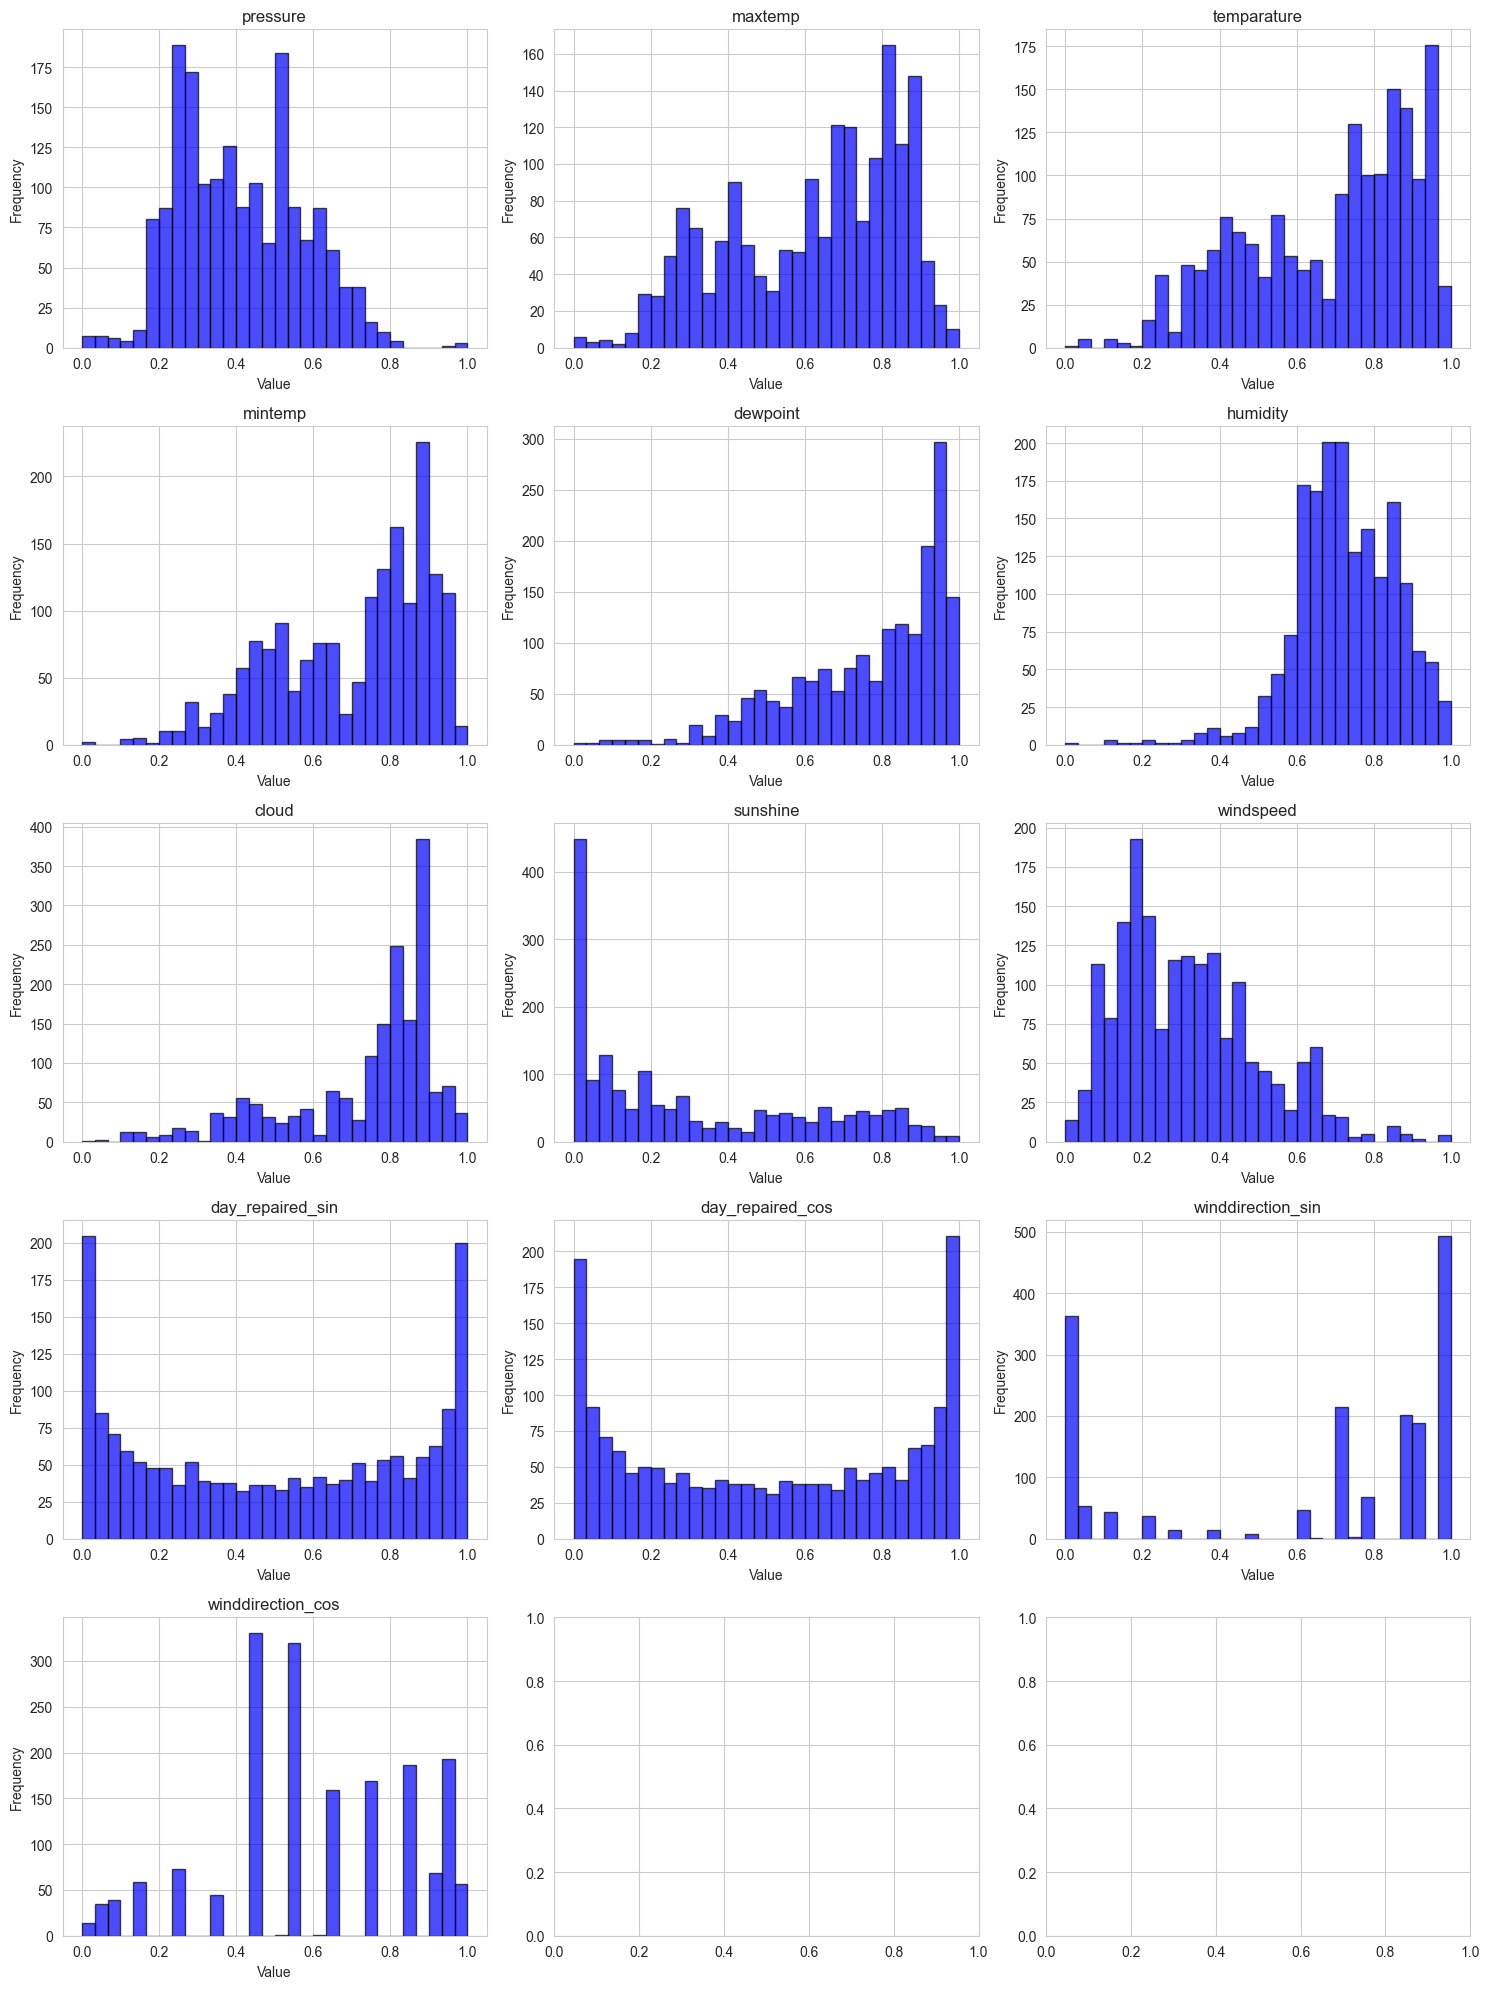

In [65]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_MinMax = scaler.fit_transform(df)
data_MinMax = pd.DataFrame(data_MinMax, columns=columns)

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    if col in data_MinMax.columns:
        axes[i].hist(data_MinMax[col], bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Robust-Scaling

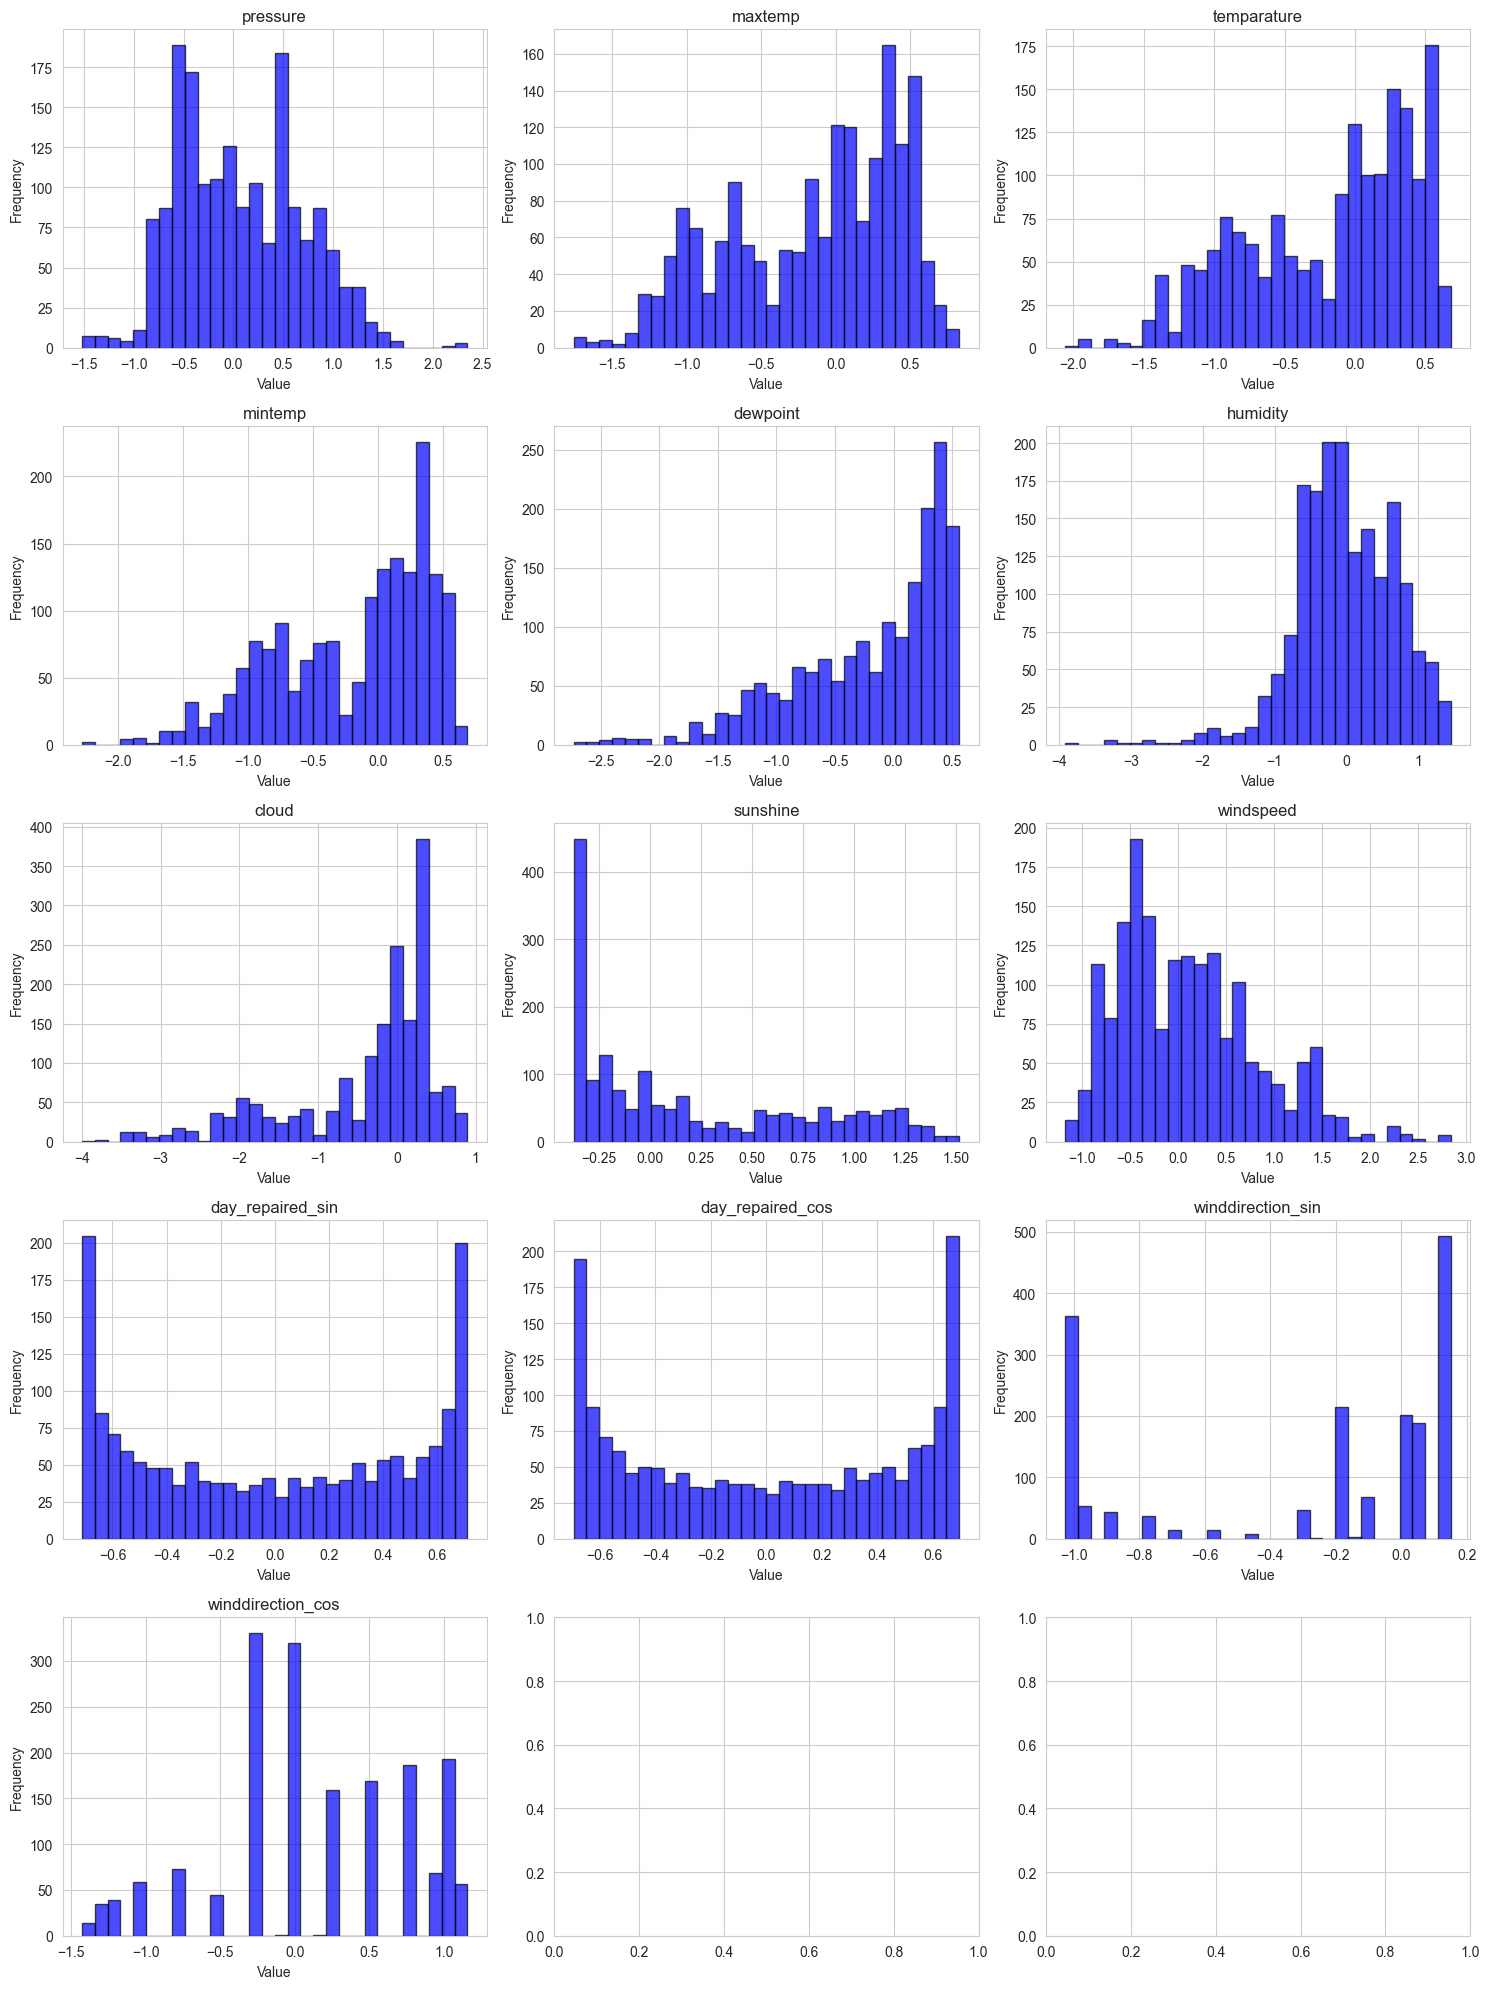

In [66]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
data_Robust = scaler.fit_transform(df)
data_Robust = pd.DataFrame(data_Robust, columns=columns)

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    if col in data_Robust.columns:
        axes[i].hist(data_Robust[col], bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Yeo-Johnson Transformation

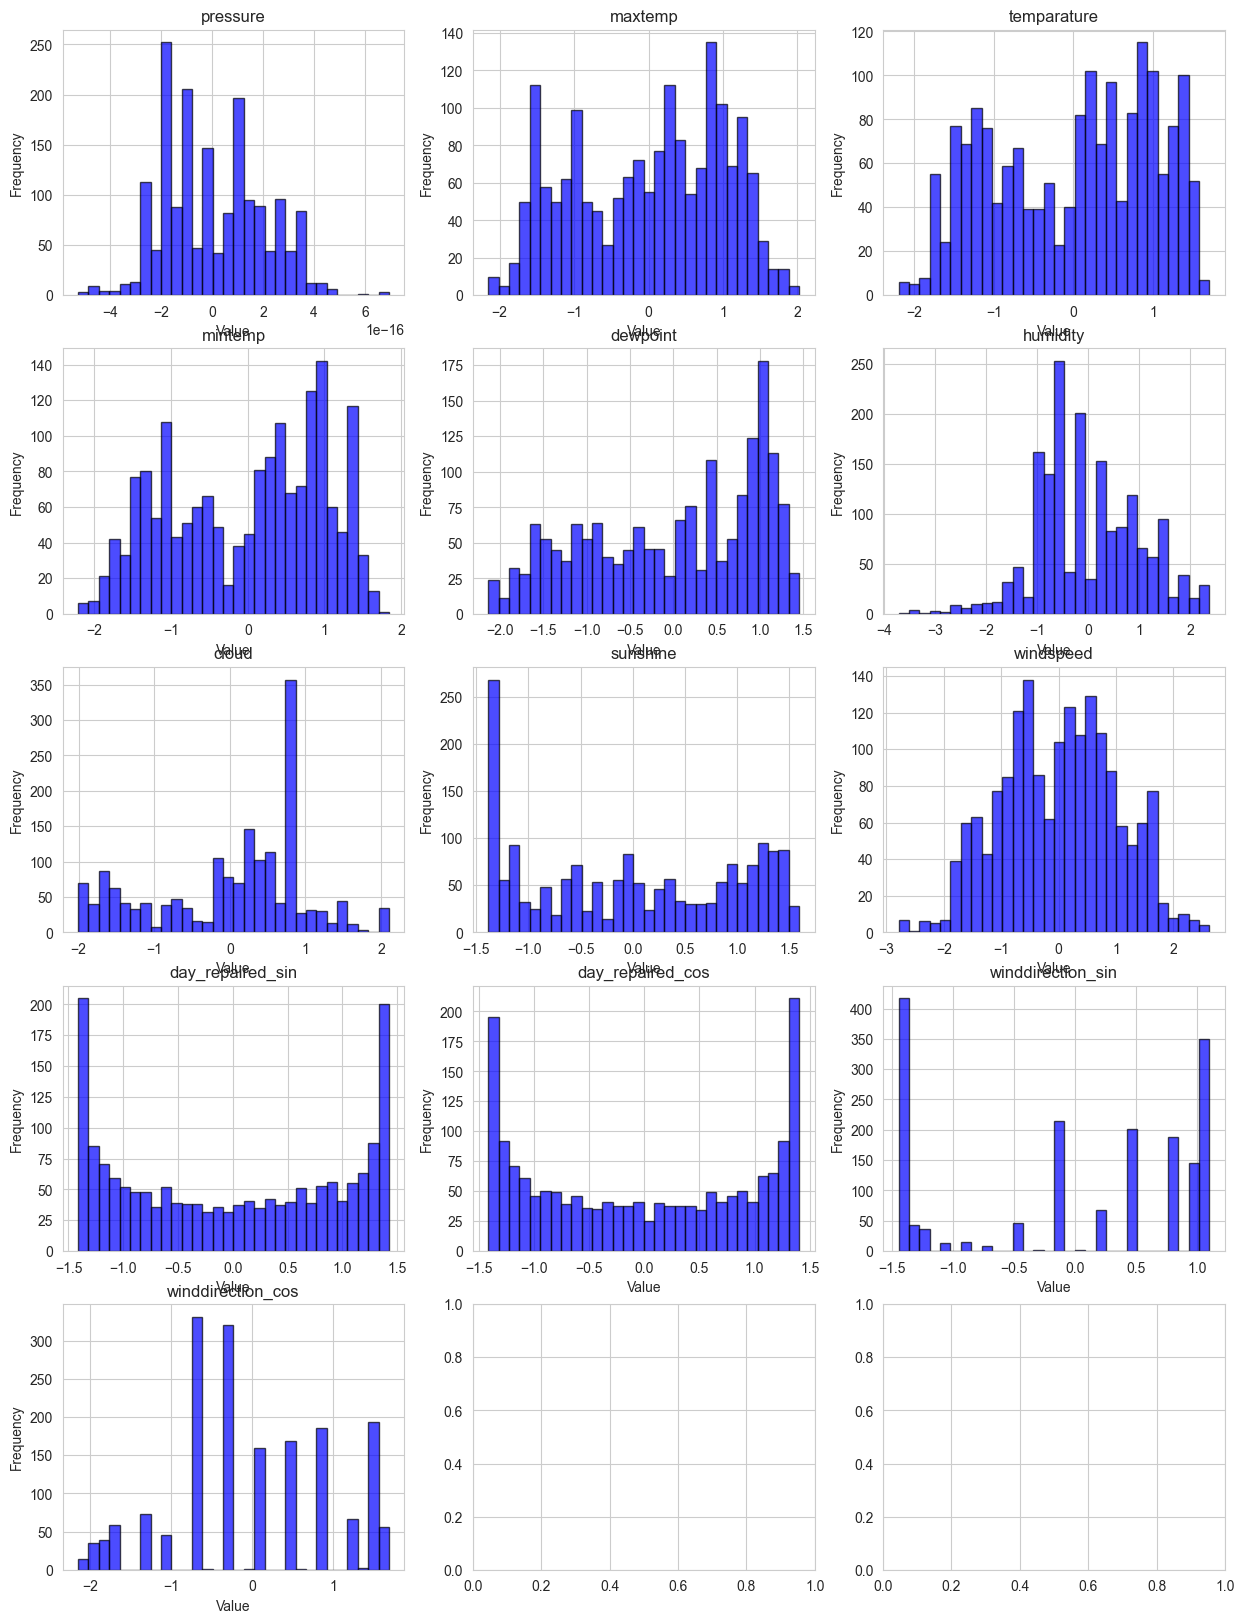

In [67]:
from sklearn.preprocessing import PowerTransformer

scaler = PowerTransformer(method='yeo-johnson')
data_yeoJohnson = scaler.fit_transform(df)
data_yeoJohnson = pd.DataFrame(data_yeoJohnson, columns=columns)

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    if col in data_yeoJohnson.columns:
        axes[i].hist(data_yeoJohnson[col], bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

### Plots combined

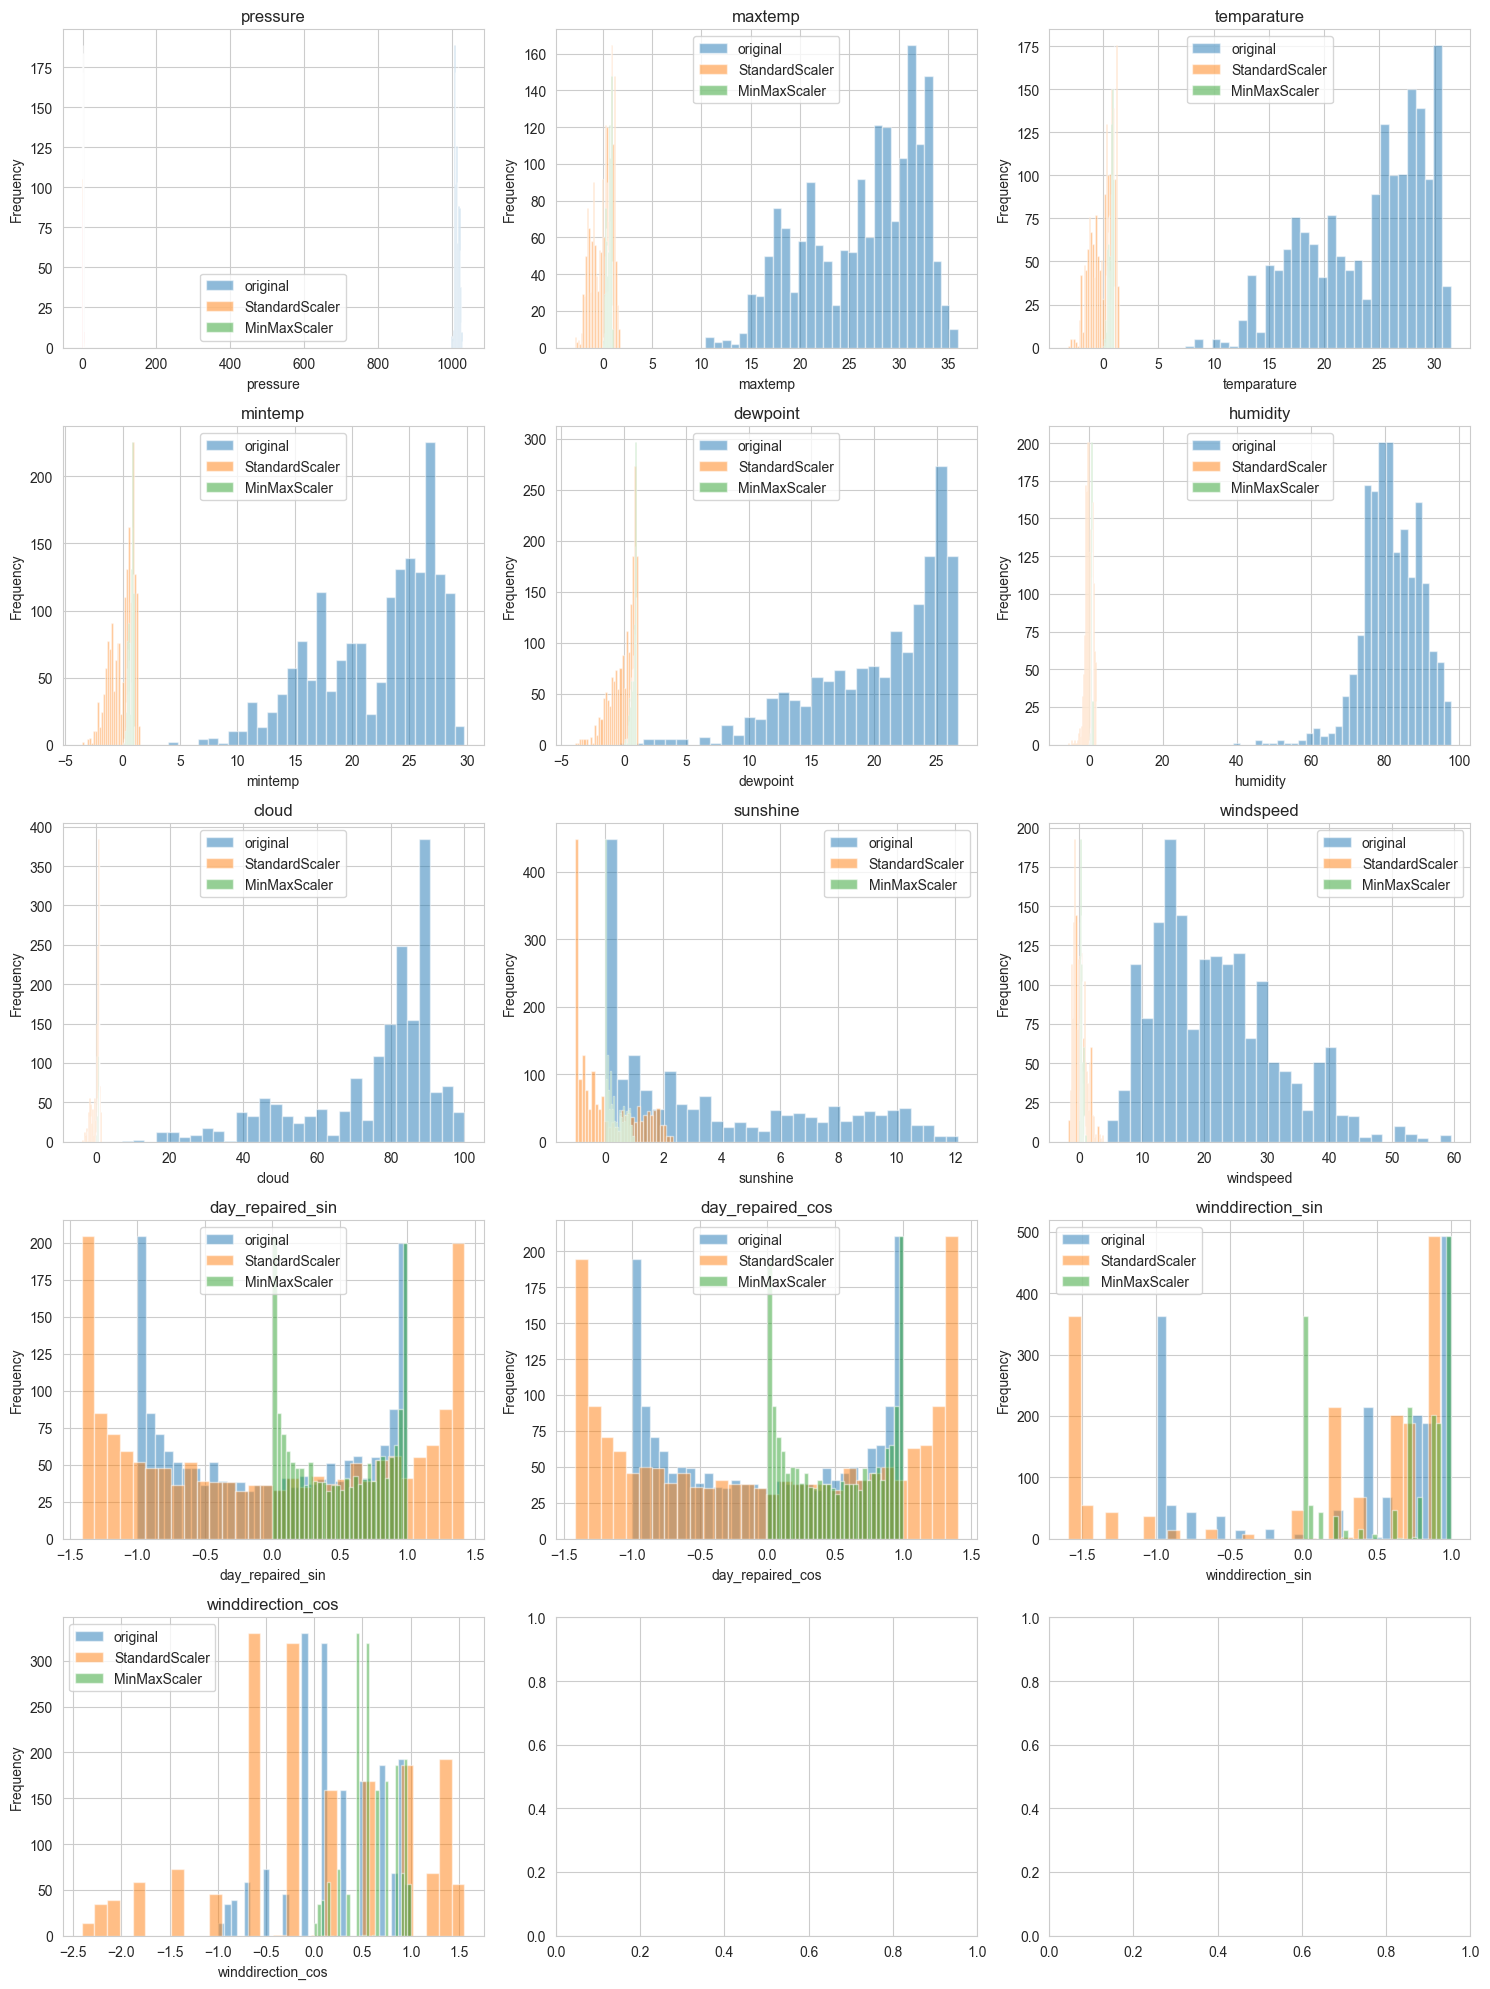

In [68]:
columns = df.columns

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    ax = axes[i]
    ax.hist(df[col], bins=30, alpha=0.5, label='original')
    ax.hist(data_standardScaler[col], bins=30, alpha=0.5, label='StandardScaler')
    ax.hist(data_MinMax[col], bins=30, alpha=0.5, label='MinMaxScaler')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()